# Completion Rate Prediction — Model Training & Evaluation

Notebook này gọi training pipeline từ `pipelines/training/pipeline.py` và visualize kết quả.

**Pipeline flow:**
1. `src/data/preprocessing.py` → Load, loại leakage, impute missing
2. `src/features/transformations.py` → 20 Tier 1 derived features
3. `src/models/` → LightGBM, XGBoost, RandomForest, Stacking
4. `src/evaluation/metrics.py` → AUC-ROC, AUC-PR, Log Loss, F1, ECE
5. Output → `data/models/model_artifacts.joblib`

In [1]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.calibration import CalibrationDisplay

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print('Ready')

Ready


## 1. Run Training Pipeline

In [2]:
from pipelines.training.pipeline import run_pipeline

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'Completion_prediction__dataset__hashing.csv'

results = run_pipeline(
    data_path=str(DATA_PATH),
    sep='\t',
    cv_folds=5,
    save=True,
)

STEP 1: Load Data
Loaded: 4,441 rows × 29 columns

STEP 2: Preprocessing
Dropped leakage: ['est_time_arrival', 'est_distance_arrival', 'estimate_dropoff_time', 'total_pay']
Dropped IDs: ['order_id', 'matching_batch_id', 'driver_id']
Dropped constant: ['travel_mode']
Imputed eta_std: 449 NaN → 0
Imputed eda_std: 449 NaN → 0

STEP 3: Feature Engineering
Created 20 derived features

Ready: 4441 samples, 40 features
Target: {0: 2395, 1: 2046}

Model parameters:
  [LightGBM]
    boosting_type: gbdt
    class_weight: None
    colsample_bytree: 0.8
    importance_type: split
    learning_rate: 0.05
    max_depth: 7
    min_child_samples: 20
    min_child_weight: 0.001
    min_split_gain: 0.0
    n_estimators: 500
    n_jobs: -1
    num_leaves: 31
    objective: None
    random_state: 42
    reg_alpha: 0.1
    reg_lambda: 1.0
    subsample: 0.8
    subsample_for_bin: 200000
    subsample_freq: 0
    verbose: -1
  [XGBoost]
    objective: binary:logistic
    base_score: None
    booster: None
 

In [3]:
# Unpack results
X = results['X']
y = results['y']
features = results['features']
oof_predictions = results['oof_predictions']
cv_results = results['cv_results']
results_df = results['results_df']

print(f'Features: {len(features)}')
results_df

Features: 40


,AUC-ROC,AUC-PR,Log Loss,F1,ECE
RandomForest,0.675865,0.617944,0.642344,0.575551,0.009255
Stacking,0.674827,0.616731,0.643292,0.568934,0.015768
XGBoost,0.648560,0.587993,0.715190,0.555836,0.124377
LightGBM,0.646140,0.595971,0.701931,0.562249,0.109046


## 2. Model Comparison

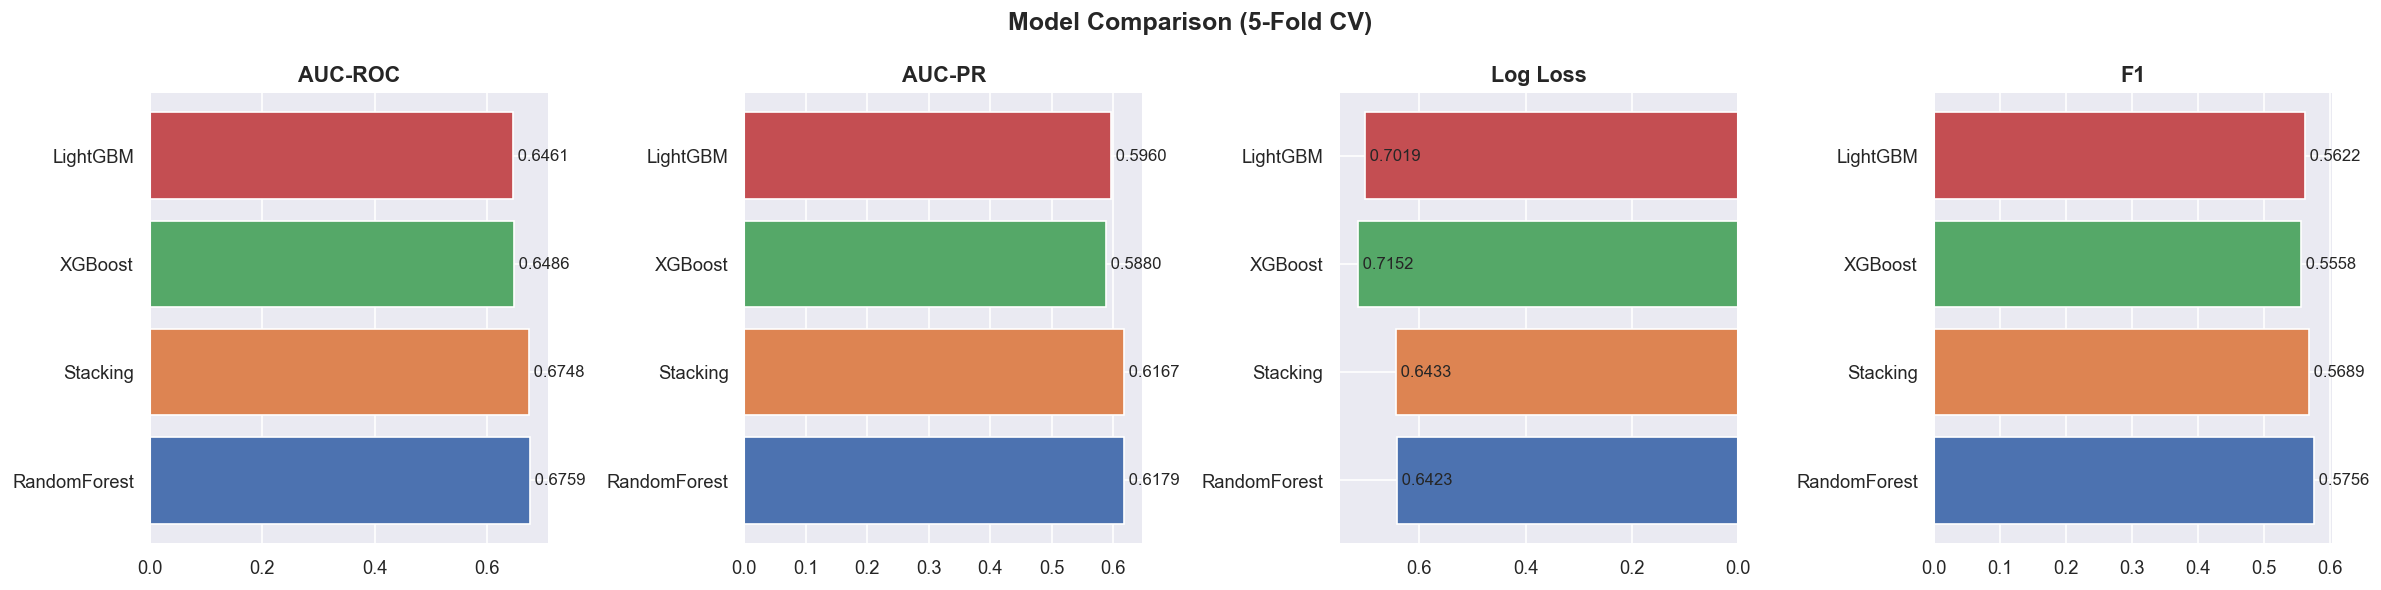

In [4]:
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ['AUC-ROC', 'AUC-PR', 'Log Loss', 'F1']

for i, metric in enumerate(metrics):
    ax = axes[i]
    vals = results_df[metric]
    bars = ax.barh(vals.index, vals.values, color=COLORS, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    for bar, val in zip(bars, vals.values):
        ax.text(val, bar.get_y() + bar.get_height() / 2,
                f' {val:.4f}', va='center', fontsize=10)
    if metric == 'Log Loss':
        ax.invert_xaxis()

plt.suptitle('Model Comparison (5-Fold CV)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. ROC Curves

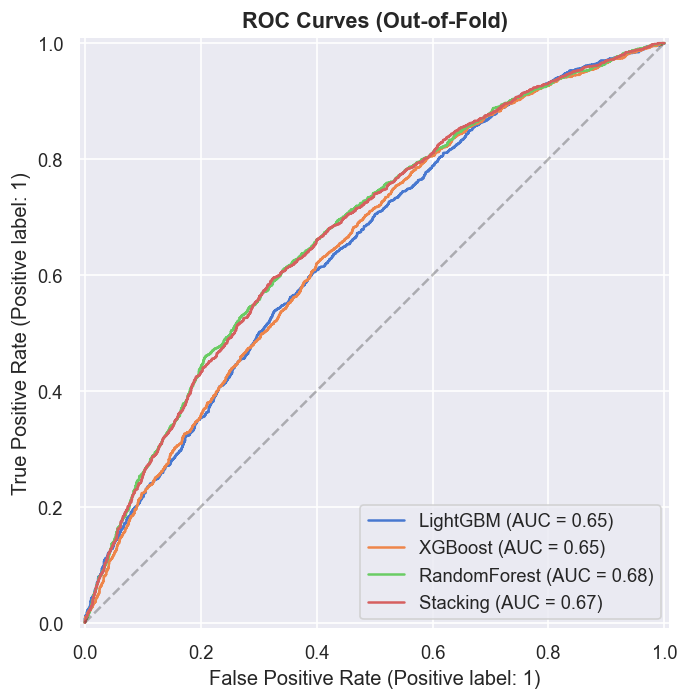

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in oof_predictions.items():
    RocCurveDisplay.from_predictions(y, proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('ROC Curves (Out-of-Fold)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Precision-Recall Curves

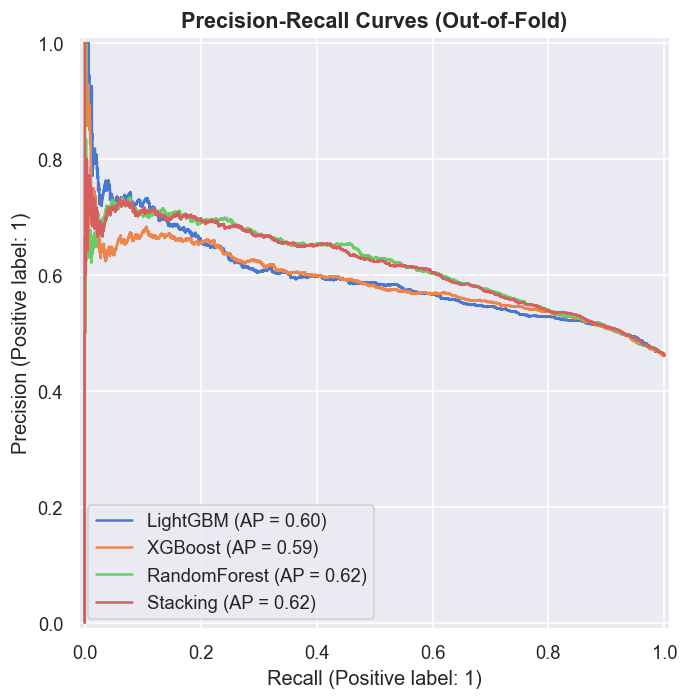

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in oof_predictions.items():
    PrecisionRecallDisplay.from_predictions(y, proba, name=name, ax=ax)
ax.set_title('Precision-Recall Curves (Out-of-Fold)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Calibration Curves

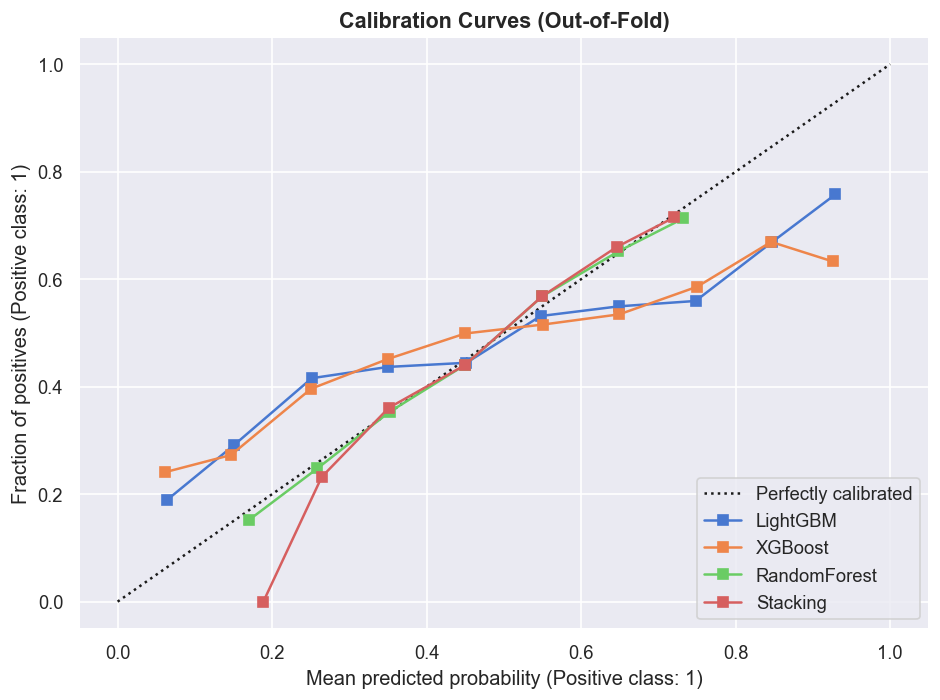

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in oof_predictions.items():
    CalibrationDisplay.from_predictions(y, proba, name=name, n_bins=10, ax=ax)
ax.set_title('Calibration Curves (Out-of-Fold)', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Confusion Matrices

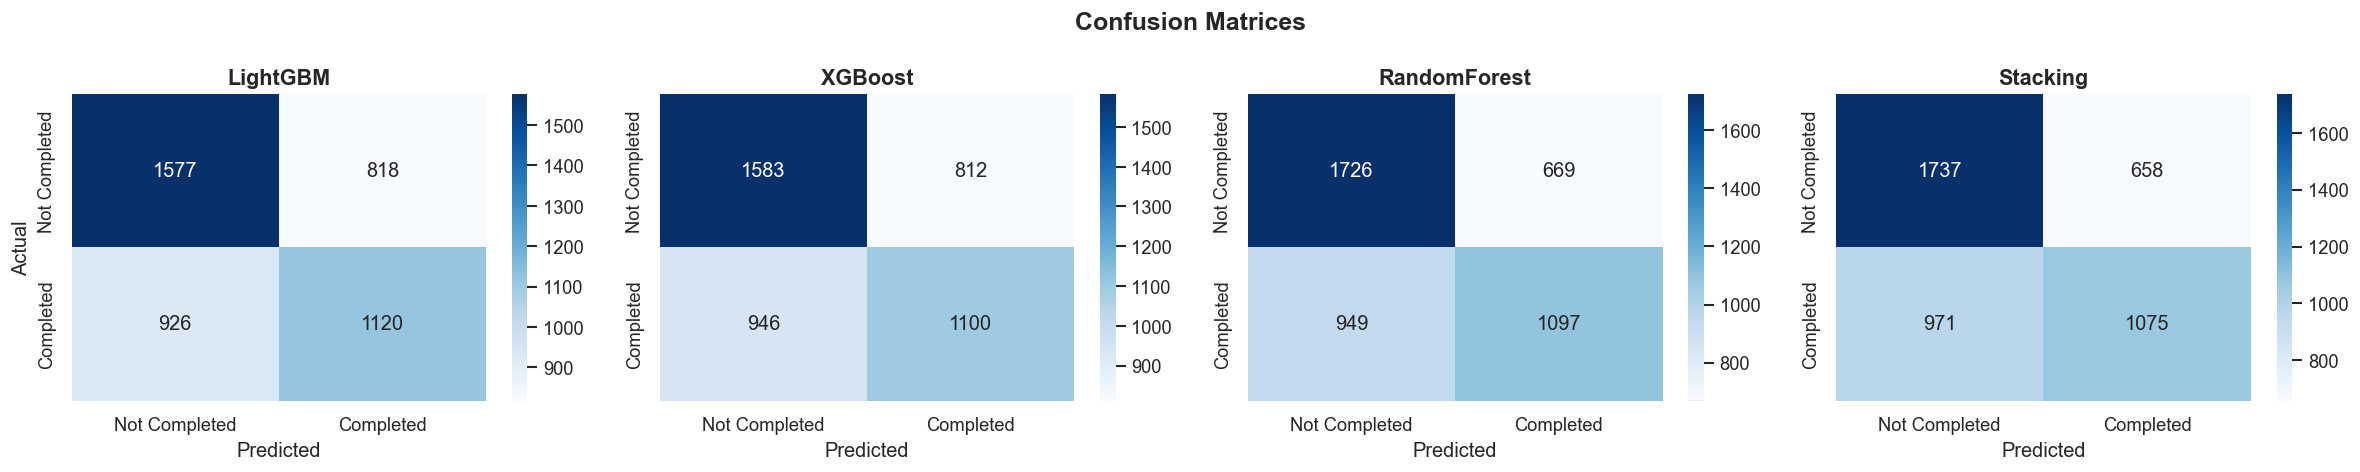

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, (name, proba) in enumerate(oof_predictions.items()):
    ax = axes[i]
    preds = (proba > 0.5).astype(int)
    cm = confusion_matrix(y, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Completed', 'Completed'],
                yticklabels=['Not Completed', 'Completed'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual' if i == 0 else '')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance

Top 15 Features (LightGBM):
                  feature  importance
user_waiting_time_seconds         700
                  eda_avg         680
               eta_per_km         645
     pickup_to_trip_ratio         642
           minute_of_hour         638
               fee_per_km         634
                  eta_avg         632
               num_orders         627
                total_fee         603
                  eda_min         595
                  eta_min         585
                  eta_std         566
           eda_confidence         524
   minutes_since_midnight         520
                 distance         519


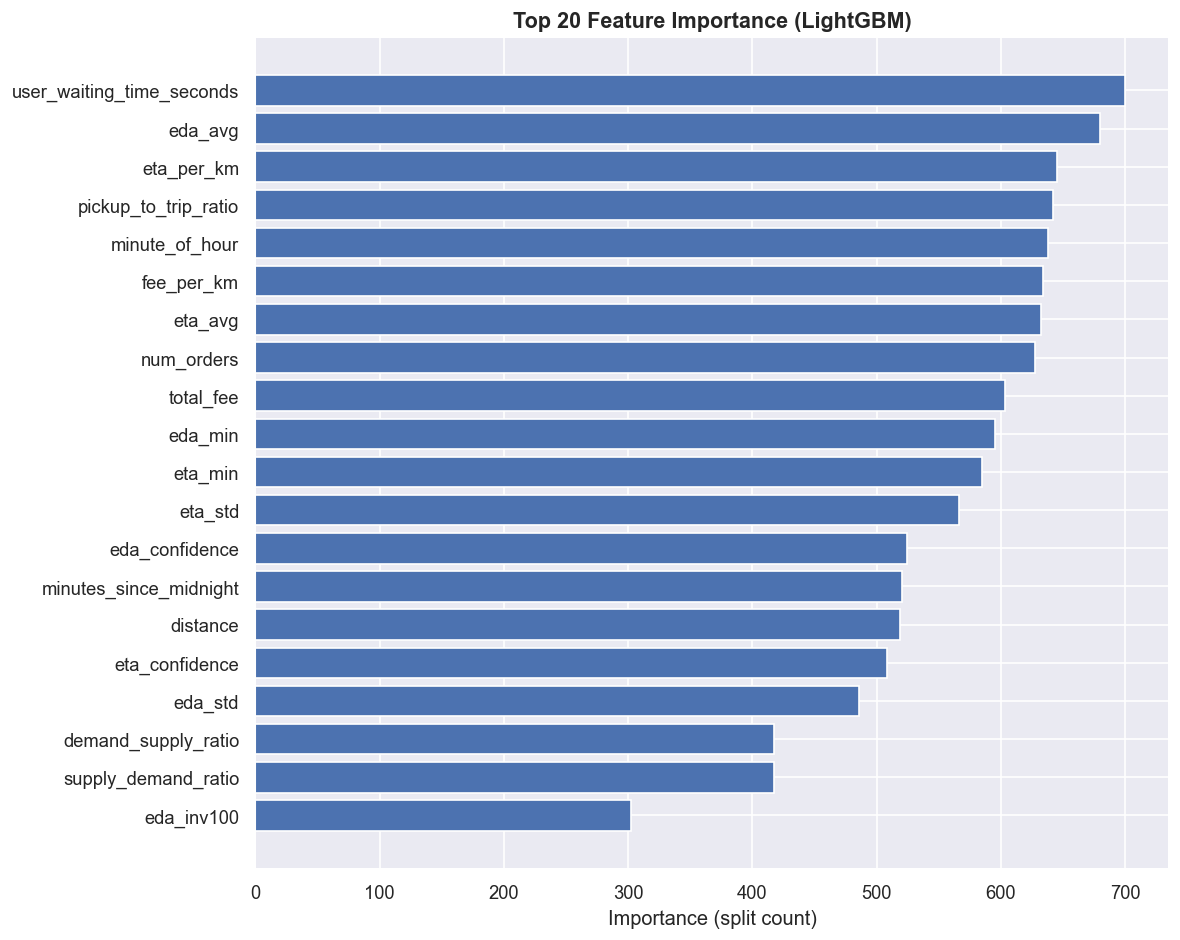

In [9]:
import joblib

artifacts = joblib.load(PROJECT_ROOT / 'data' / 'models' / 'model_artifacts.joblib')
importance = artifacts['feature_importance']

print('Top 15 Features (LightGBM):')
print(importance.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1],
        color='#4C72B0', edgecolor='white')
ax.set_title('Top 20 Feature Importance (LightGBM)', fontweight='bold')
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
plt.show()

## 8. Classification Reports

In [10]:
from src.evaluation.metrics import print_evaluation

for name, proba in oof_predictions.items():
    print_evaluation(y, proba, name)


 LightGBM
  AUC-ROC     : 0.6461
  AUC-PR      : 0.5960
  Log Loss    : 0.7019
  F1          : 0.5622
  ECE         : 0.1090

               precision    recall  f1-score   support

Not Completed       0.63      0.66      0.64      2395
    Completed       0.58      0.55      0.56      2046

     accuracy                           0.61      4441
    macro avg       0.60      0.60      0.60      4441
 weighted avg       0.61      0.61      0.61      4441


 XGBoost
  AUC-ROC     : 0.6486
  AUC-PR      : 0.5880
  Log Loss    : 0.7152
  F1          : 0.5558
  ECE         : 0.1244

               precision    recall  f1-score   support

Not Completed       0.63      0.66      0.64      2395
    Completed       0.58      0.54      0.56      2046

     accuracy                           0.60      4441
    macro avg       0.60      0.60      0.60      4441
 weighted avg       0.60      0.60      0.60      4441


 RandomForest
  AUC-ROC     : 0.6759
  AUC-PR      : 0.6179
  Log Loss    : 0.64

## 9. Prediction Distribution

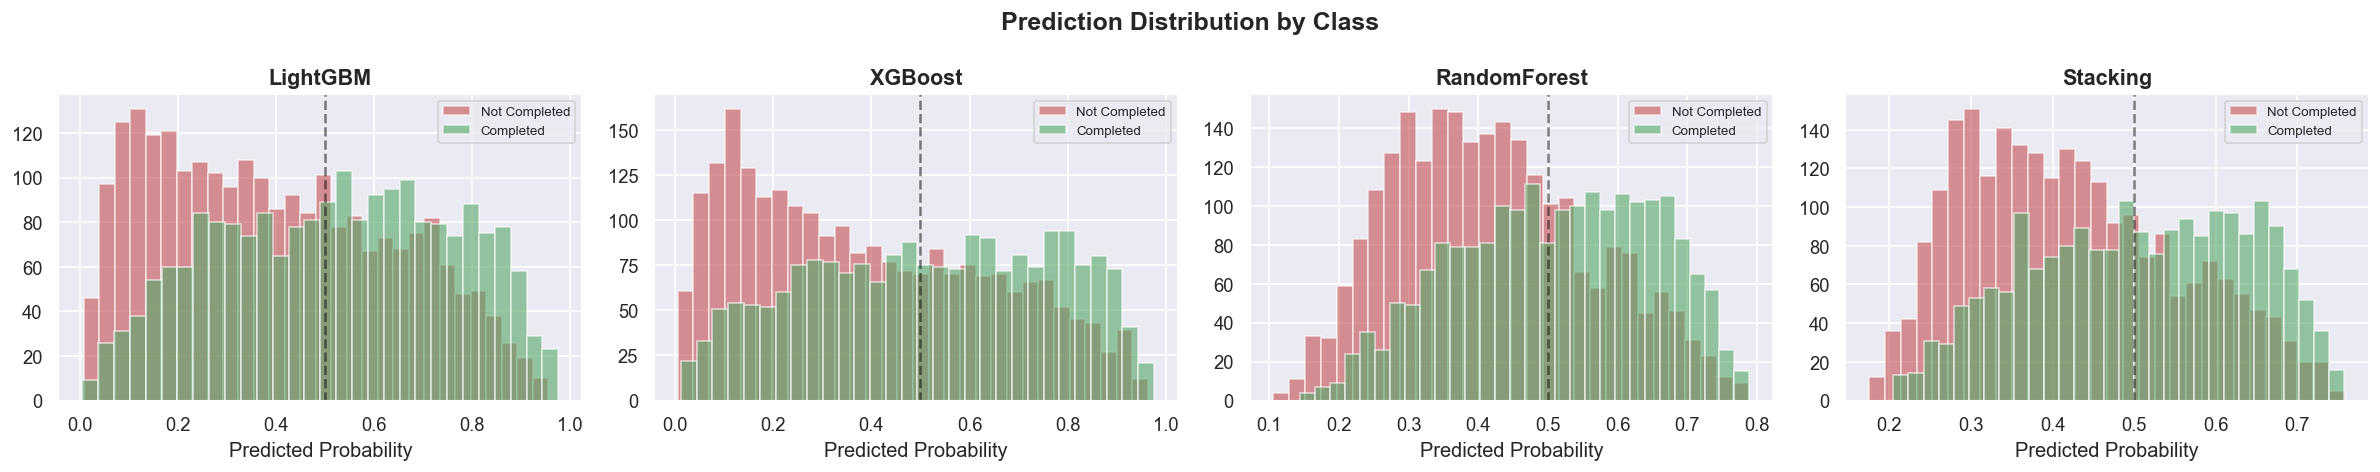

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, (name, proba) in enumerate(oof_predictions.items()):
    ax = axes[i]
    ax.hist(proba[y == 0], bins=30, alpha=0.6, label='Not Completed', color='#C44E52')
    ax.hist(proba[y == 1], bins=30, alpha=0.6, label='Completed', color='#55A868')
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted Probability')
    ax.legend(fontsize=8)
plt.suptitle('Prediction Distribution by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()